In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from typing import Tuple, List
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import pandas as pd
import numpy as np
import glob
import random
import os
import torchvision.transforms as transforms
import time

In [2]:
def show_32x32(img, title):
    """
    img: torch.Tensor or numpy array of shape (32, 32)
         values assumed in [0, 1]
    """
    # normalize to [0, 1]
    #img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    plt.imshow(img, cmap="gray_r", vmin=0, vmax=1)  # gray_r flips: 1=black, 0=white
    plt.title(title)
    plt.axis('off')
    plt.show()


In [3]:
# changed function so that combined data doesn't always have to be saved to a file
def combineFiles(quantity, infolder, outfolder, inFeatures, saveFile=True):
    # passed parameters are mutable in python (will be modified in function if not copied)
    inputFeatures = inFeatures.copy()
    if len(inFeatures) < 13:
        inputFeatures.append("FireMask")

    # List of all csv files in the specified folder)
    all_files = glob.glob(f"{infolder}/*.csv")  
    max = len(all_files)

    if quantity > max:
        print(f"Too many files requested, max {max}")
        return 0, None

    # shuold be able to mod this later to get train and test splits, for now just randomly selects 
    # quantity number of files from the folder
    files = os.listdir(infolder)
    rand_files = random.sample(files, quantity)

    combined_df = pd.DataFrame()
    for i in range(len(rand_files)):
        f = infolder + rand_files[i]
        curr = pd.read_csv(f)
        curr = curr[inputFeatures]
        combined_df = pd.concat([combined_df, curr])
        rand_files[i] = f
        

    if (saveFile):
        # Save to a single CSV
        combined_df.to_csv(f"{outfolder}/split{quantity:d}.csv", index=False)
        return rand_files, f"{outfolder}/split{quantity}.csv"
    else:
        return rand_files, combined_df

In [4]:
"""Randomly axis-align crop input and output image tensors.
Args:
    crop_img: tensor with dimensions HWC.
    output_img: tensor with dimensions HWC.
    desired_size: side length (square) to crop to.
    num_in_channels: number of channels in crop_img.
    num_out_channels: number of channels in output_img.
Returns:
    input_img: tensor with dimensions HWC.
    output_img: tensor with dimensions HWC.
"""
def random_crop_io(input_img: torch.Tensor, output_img: torch.Tensor,
    desired_size: int, num_in_channels: int, num_out_channels: int) -> Tuple[torch.Tensor, torch.Tensor]:

    # order should be CWH (no batch dim yet!!)
    # concat first (over CHANNELS, axis=1) so that image and label will be cropped the same, then separate again
    combined = torch.cat([input_img, output_img], dim=0) # CHW ordering (channel = dim0) rather than HWC as in tf. dim same as axis
    cropTransform = transforms.RandomCrop(size=(desired_size, desired_size))
    combined = cropTransform(combined)
    
    # size CHW (channel first)
    input_img = combined[0:num_in_channels, :, :]
    output_img = combined[-num_out_channels:, :, :]

    return input_img, output_img
    
    
    
"""Center crops input and output image tensors.
Args:
    input_img: tensor with dimensions HWC.
    output_img: tensor with dimensions HWC.
    sample_size: side length (square) to crop to.
Returns:
    input_img: tensor with dimensions HWC.
    output_img: tensor with dimensions HWC.
"""
def center_crop_io(input_img: torch.Tensor, output_img: torch.Tensor,
    desired_size: int) -> Tuple[torch.Tensor, torch.Tensor]:

    # order is CHW not HWC as in torch so 0=channel, 1=height, 2=width
    central_fraction = desired_size / input_img.shape[1]
    cropH = int(input_img.shape[1]*central_fraction)
    cropW = int(input_img.shape[2]*central_fraction)

    cropTransform = transforms.CenterCrop(size=(cropH, cropW))
    input_img = cropTransform(input_img)
    output_img = cropTransform(output_img)

    return input_img, output_img


"""
Get mean and std from combined data from selected data split. Functionality added to read from 
df instead of always from a file
"""
def getNormStats(combined, INPUT_FEATURES, readFile=True):
    # assume that if readFile is true, then combined is a filename and if false its a df
    if (readFile): df = pd.read_csv(combined)
    else: df = combined

    if "FireMask" in df.columns:
        df = df.drop("FireMask", axis=1)

    std = df.std(axis=0)
    mean = df.mean(axis=0)
    return mean[INPUT_FEATURES].to_numpy(), std[INPUT_FEATURES].to_numpy() 

In [5]:
def genFakeTarget_init(prevmask, hw):
    prevmask_r = prevmask.values.reshape(hw, hw, 1)
    faketarget = np.zeros((hw, hw, 1))
    ditr = np.nditer(prevmask_r, flags=['multi_index']) # n-dim iter for a matrix

    for elem in ditr:
        if elem==1:
            br = ditr.multi_index[0] # curr row
            bc = ditr.multi_index[1] # curr col
            faketarget[br][bc][0] = 1.0                                # [r][c]= 1.0 (copying prev mask fires)
            if (br - 1) >= 0: faketarget[br-1][bc][0] = 1.0     # [r-1][c]
            if (br + 1) < hw: faketarget[br+1][bc][0] = 1.0      # [r][c-1]
            if (bc - 1) >= 0: faketarget[br][bc-1][0] = 1.0     # [r][c+1]
            if (bc + 1) < hw: faketarget[br][bc+1][0] = 1.0      # [r+1][c]
            
    return faketarget


def genFakeTarget(data, hw):
    faketarget = np.zeros((hw*hw, 1))
    #ditr = np.nditer(data, flags=['multi_index']) # n-dim iter for a matrix
    for idx, row in data.iterrows():
        if (row["pdsi"]+row["NDVI"]) >0.68:
            faketarget[idx] = 1.0
        else: faketarget[idx] = 0.0               

    # show = faketarget.copy()
    # print(f"max: {faketarget.min()}, min: {faketarget.max()}")
    # show = show.reshape(64,64,1)
    # show_32x32(show, "fake")
    return faketarget

# df = pd.read_csv("../03DataVisualization/renamed-raw-csvs/18.csv")
# df = df[INPUT_FEATURES] # sort features into consistent order
# mean, std = getNormStats("../03DataVisualization/renamed-raw-csvs/18.csv") # get mean and std from combined file of entered filepaths
# df_norm = (df - mean)/std 
# #print(df_norm["sph"], df_norm["vs"])
# print(df_norm["sph"][0]+df_norm["vs"][0] > 0.5)
# genFakeTarget(df_norm, 64);

In [6]:
INPUT_FEATURES = ['elevation', 'th', 'vs',  'tmmn', 'tmmx', 'sph', 
                  'pr', 'pdsi', 'NDVI', 'population', 'erc', 'PrevFireMask']

"""
Taking out clip and normalize/clip and scale inputs and just automatically normalizing all the data. 
Adding a variable for whether fake target data should be generated
4-13: removed combined file variable bc stopped using it at some point
"""
class FireDataset(Dataset):
    def __init__(self, file_paths:List[str], mean, std, data_size=64, crop_size=32, in_channels=12,  
                 random_crop=True, center_crop=False, crops_per_file=1, fake_target=False):
        
        self.file_paths = file_paths
        self.center_crop = center_crop
        self.random_crop = random_crop
        self.data_size = data_size
        self.crop_size = crop_size
        self.crops_per_file = crops_per_file
        self.in_channels = in_channels
        self.fake_target = fake_target
        self.mean = mean
        self.std = std

        # read in all samples at once: leave preprocessing to getitem() method
        # if fake_target is false, fake labels will be all -5. if its true, both fake and real labels 
        # will have data in them
        self.in_images = []
        self.fake_labels = []
        self.real_labels = [] 

        #self.base_dir = "C:\\Users\\rball\\OneDrive\\Documents\\school\\00 GRADUATE\\Thesis\\"
        for file in self.file_paths:
            #curr_file = self.base_dir + file
            df = pd.read_csv(file)

            # can't just select the first column since they are not always in order
            rtarget = df["FireMask"].astype(np.float32)
            rtarget[rtarget == -1] = 0.0 # replacing "ambiguous" placeholder with "no fire" val
            rtarget = np.array(rtarget).reshape(data_size, data_size, 1)
            rlabel = torch.tensor(rtarget, dtype=torch.float32).permute(2,0,1)
            self.real_labels.append(rlabel)

            # other feature processing
            data = df.drop('FireMask', axis=1).astype(np.float32)
            data = data[INPUT_FEATURES] # sort features into consistent order
            #mean, std = getNormStats(self.comb_file) # get mean and std from combined file of entered filepaths
            self.std[self.std==0]=1
            data_norm = (data - self.mean)/self.std

            # target/label processing
            if self.fake_target is True:
                ftarget = genFakeTarget(data_norm, data_size)
                #ftarget = genFakeTarget_init(data["PrevFireMask"], data_size)
                ftarget = np.array(ftarget).reshape(data_size, data_size, 1)
                flabel = torch.tensor(ftarget, dtype=torch.float32).permute(2,0,1)
                self.fake_labels.append(flabel)
            else: self.fake_labels.append(torch.full((data_size, data_size, 1), -5.0)) # fill with obv incorrect vals when fake_target is false

            # permute to get in shape CHW. DONT unsqueeze for batch dim as that is added by DataLoader!!!!
            data_norm = data.values.reshape(data_size, data_size, 12)
            image = torch.tensor(data_norm, dtype=torch.float32).permute(2,0,1)
            self.in_images.append(image) 
   

    def __len__(self):
        # get more than 1 cropped sample per file
        return len(self.file_paths*self.crops_per_file)
    

    def __getitem__(self, idx): # GETITEM RETURNS WITH SIZE CHW
        file_idx = idx // self.crops_per_file # "//" floors the division result

        # in_images is already a list of tensors in the correct shape
        input_img = self.in_images[file_idx]
        r_output_img = self.real_labels[file_idx]
        f_output_img = self.fake_labels[file_idx]

        if self.random_crop and self.center_crop:
            raise ValueError('Cannot have both random_crop and center_crop be True')

        # CROP METHODS NOT CURRENTLY SET TO WORK WITH BOTH REAL AND FAKE DATA
        if self.random_crop:
            input_img, f_output_img = random_crop_io(input_img, f_output_img, desired_size=self.crop_size, 
                                        num_in_channels=self.in_channels, num_out_channels=1)
        elif self.center_crop:
            input_img, f_output_img = center_crop_io(input_img, f_output_img, desired_size=self.crop_size)
            
        #print("input shape:", input_img.shape, " output shape:", output_img.shape )
        return input_img, r_output_img, f_output_img
        


In [7]:
# FOR MODEL TESTING
BATCH_SIZE=5

# RULE 1
# switched to saving to df instead of new file everytime: this whole part does not use file I/O except for reading in the files initially
split18files, s18_combdf = combineFiles(18, "../03DataVisualization/renamed-raw-csvs/", "../03DataVisualization/combo-files-for-norm", INPUT_FEATURES, saveFile=False)
mean, std = getNormStats(s18_combdf, INPUT_FEATURES, readFile=False)
allfiles_dataset = FireDataset(split18files, mean, std, random_crop=True, center_crop=False, crops_per_file=3, fake_target=True)

In [19]:
torch.manual_seed(int(time.time()))
trainset, testset = torch.utils.data.random_split(allfiles_dataset, [0.8, 0.2])
print(len(trainset), len(testset))

trainLoader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
testLoader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=True)


44 10


In [39]:
hw_size = 32 # cropping
c_size = 12
flat_size = hw_size*hw_size*c_size
inner_size = (int) (flat_size*1.2)

class WildfireMLP(nn.Module):
    def __init__(self, hw_size, c_size):
        super().__init__() # calling/initializing the nn Module

        # adding an initial conv layer to learn the data gen rule
        # can do k=1, s=1, p=0 OR k=3, s=1, p=1 to keep output size same as input
        self.conv = nn.Conv2d(c_size, c_size, kernel_size=1, stride=1, padding=0)

        #assuming right now that input will be passed as batchsize, csize, hwsize, hwsize
        self.flatten = nn.Flatten(start_dim=1)

        self.linear1 = nn.Linear(in_features=flat_size, out_features=inner_size)
        self.bn1 = nn.BatchNorm1d(num_features=inner_size)
        self.relu1 = nn.ReLU()

        self.linear2 = nn.Linear(in_features=inner_size, out_features=inner_size)
        self.bn2 = nn.BatchNorm1d(num_features=inner_size)
        self.relu2 = nn.ReLU()

        self.linear3 = nn.Linear(in_features=inner_size, out_features=(hw_size*hw_size))

        #self.bn1 = nn.BatchNorm1d(num_features=(hw_size*hw_size))
        self.sigmoid = nn.Sigmoid()
        self.unflatten = nn.Unflatten(dim=1, unflattened_size=(1, hw_size, hw_size))

        # weight initialization: default is uniform distribution

    def forward(self, x):
        x = self.conv(x)
        #print(f"after conv: {x[0]}")
        x = self.flatten(x)

        x = self.linear1(x)

        x = self.bn1(x)
        x = self.relu1(x)
        x = self.linear2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.linear3(x)
        #print(f"after linear{x[0]}")
        #x = self.bn1(x)
        #print(f"after bn: {x[0]}")
        x = self.sigmoid(x)
        # unflatten
        x = self.unflatten(x)
 
        return x



In [10]:
def recall(true_target, predicted_target):

    # zeros should already be replaced but do it anyway just in case
    true_target = torch.where(true_target < 0, 0, true_target)
    
    predicted_TP = torch.sum(torch.logical_and(true_target, predicted_target)).item() # TP, or the number of correct positives predicted
    all_true_pos = torch.sum(true_target).item()                                      # TP + FN, or all actual positives
    
    if all_true_pos == 0:
        if torch.sum(true_target).item() == 0:
            return 1.0, -1, -1
        else: return 0.0, -1, -1
    
    recall = predicted_TP/all_true_pos
    return recall, predicted_TP, all_true_pos


def precision(true_target, predicted_target):
    # zeros should already be replaced but do it anyway just in case
    true_target = torch.where(true_target < 0, 0, true_target)
    
    # item() to make sure we return a float
    predicted_TP = torch.sum(torch.logical_and(true_target, predicted_target)).item() # TP, or the number of correct positives predicted
    all_pred_pos = torch.sum(predicted_target).item()                                 # TP + FP, or all predicted positivies
    
    if all_pred_pos == 0:
        if torch.sum(true_target).item() == 0:
            return 1.0, -1, -1
        else: return 0.0, -1, -1
    
    precision = predicted_TP/all_pred_pos
    return precision, predicted_TP, all_pred_pos

In [40]:
import torch.optim as optim
numepochs = 8
model = WildfireMLP(hw_size, c_size)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loader = trainLoader

ftarget = True
TP = 0.0
TPplusFP = 0.0
TPplusFN = 0.0
i=0
plot_loss = []

for epoch in range(numepochs):
    model.train()
    running_loss = 0.0
    
    for inputs, rlabels, flabels in loader:
        optimizer.zero_grad()

        outputs = model(inputs)
        
        if ftarget: labels=flabels
        else: labels=rlabels

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # metrics
        _, tempTP, tempTPFP = precision(flabels, (outputs.detach()>0.5).int())
        _, _, tempTPFN = recall(flabels, (outputs.detach()>0.5).int())
        TP += tempTP
        TPplusFP += tempTPFP
        TPplusFN +=tempTPFN

        # keep track of loss by epoch
        running_loss += loss
        i+=1
    
    epoch_lossavg = running_loss/BATCH_SIZE
    plot_loss.append(epoch_lossavg.item())
    epoch_prec = TP/TPplusFP if TPplusFP>0 else 0.0
    epoch_rec = TP/TPplusFN if TPplusFN>0 else 0.0
    print(f"Epoch [{epoch+1}/{numepochs}]  Loss: {epoch_lossavg:.6f} Precision: {epoch_prec:.6f} Recall: {epoch_rec:.6f}")
    TP=0.0; TPplusFP=0.0; TPplusFN=0.0




Epoch [1/8]  Loss: 1.929452 Precision: 0.603895 Recall: 0.580481
Epoch [2/8]  Loss: 1.659933 Precision: 0.607386 Recall: 0.544520
Epoch [3/8]  Loss: 1.577174 Precision: 0.653017 Recall: 0.538320
Epoch [4/8]  Loss: 1.118328 Precision: 0.617859 Recall: 0.691030
Epoch [5/8]  Loss: 2.231084 Precision: 0.583812 Recall: 0.660032
Epoch [6/8]  Loss: 1.633093 Precision: 0.536820 Recall: 0.389002
Epoch [7/8]  Loss: 1.068691 Precision: 0.697010 Recall: 0.649397
Epoch [8/8]  Loss: 1.053677 Precision: 0.760029 Recall: 0.784267


avg loss on test set: 0.8044501543045044



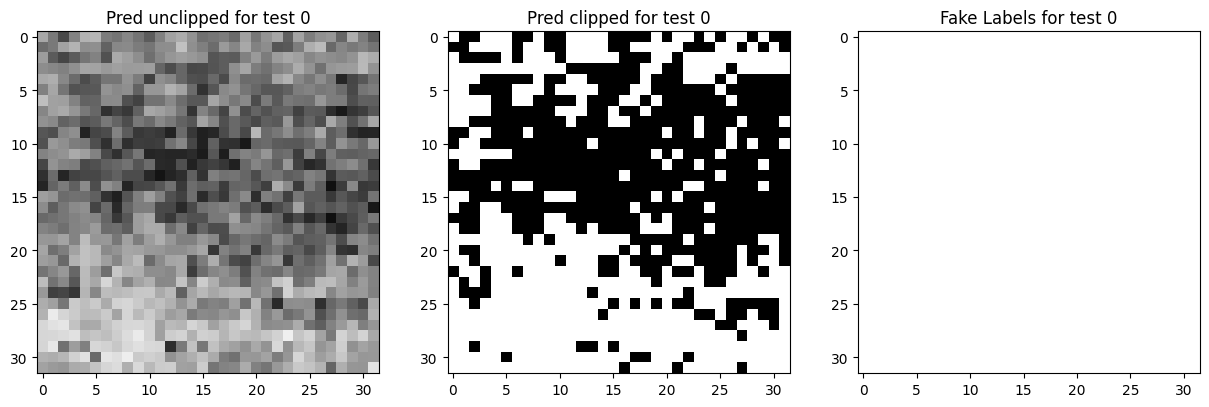

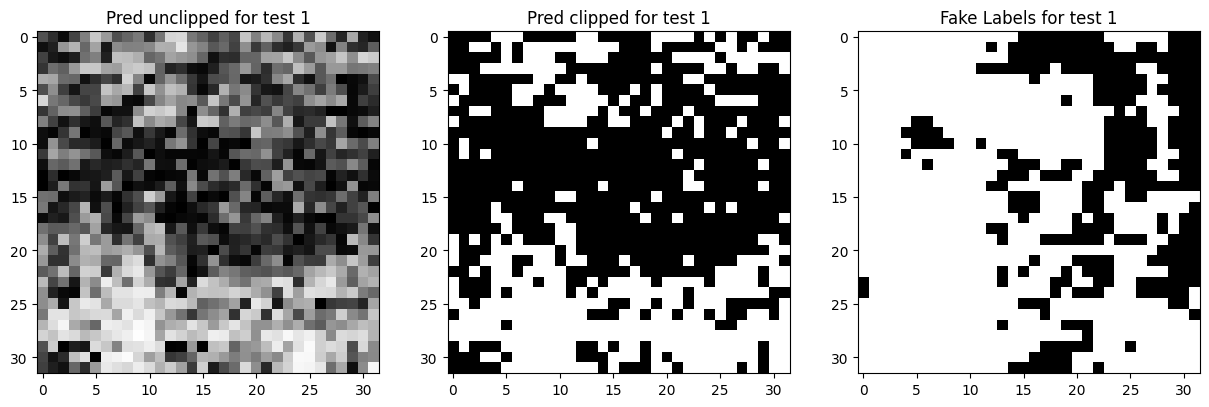

In [41]:
model.eval()
test_loss = 0.0
j=0
with torch.no_grad():
    for test_in, _, test_flabels in testLoader:
        test_out = model(test_in)
        loss = criterion(test_out, test_flabels)
        test_loss += loss 
        test_clip = (test_out>=0.5).float()

        fig, ax = plt.subplots(1,3, figsize=(15,5))
        ax[0].imshow(test_out.numpy()[0,0,:,:], cmap="gray_r", vmin=0, vmax=1)
        ax[0].set_title(f"Pred unclipped for test {j}")
        ax[1].imshow(test_clip.numpy()[0,0,:,:], cmap="gray_r", vmin=0, vmax=1)
        ax[1].set_title(f"Pred clipped for test {j}")
        ax[2].imshow(test_flabels[0,0,:,:], cmap="gray_r", vmin=0, vmax=1)
        ax[2].set_title(f"Fake Labels for test {j}")
        j+=1
    
avg_testloss = test_loss/(len(testLoader.dataset)/BATCH_SIZE)
print(f"avg loss on test set: {avg_testloss}\n")

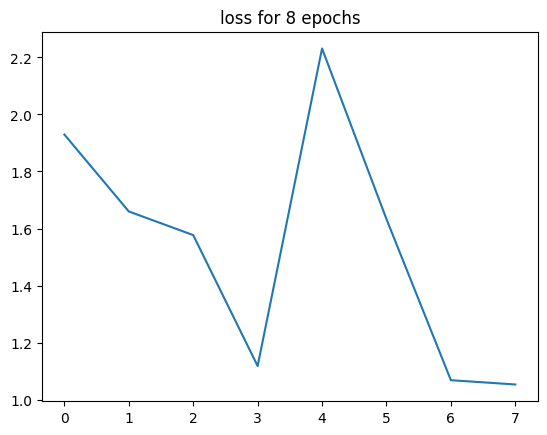

In [42]:
plt.figure()
epochs = [i for i in range(len(plot_loss))]
plt.plot(epochs, plot_loss)
plt.title(f"loss for {numepochs} epochs")
plt.show()

### EDA: Spearman correlation analysis
Next section runs spearman correlation on each datafile. Pandas corr method returns an fxf table for correlation for  
every feature with every other feature; full tables for each file are saved in new csv files. The first line of each  
(correlation between each variable and FireMask) was saved to a new dataframe to be printed and put into an excel  
sheet for more analysis. The point of this was originally to figure out which variables to start with for fake  
target generation rules

In [ ]:
INPUT_FEATURES = ['elevation', 'th', 'vs',  'tmmn', 'tmmx', 'sph', 
                  'pr', 'pdsi', 'NDVI', 'population', 'erc', 'PrevFireMask']
INPUT_FEATURES.insert(0,"FireMask")
pd.set_option("display.expand_frame_repr", False)

corrtable = pd.DataFrame()
for i in range(19):
    filename = f"../03DataVisualization/renamed-raw-csvs/{i:02d}.csv"
    df = pd.read_csv(filename)
    df = df[INPUT_FEATURES]
    ctable = df.corr(method='spearman')
    corrtable = pd.concat((corrtable, ctable.head(1)), axis=0)
    ctable.to_csv(f"../03DataVisualization/spearman-correlation-tables/{i:02d}_scorr.csv")



INPUT_FEATURES = ['elevation', 'th', 'vs',  'tmmn', 'tmmx', 'sph', 
                  'pr', 'pdsi', 'NDVI', 'population', 'erc', 'PrevFireMask']


combofile = "../03DataVisualization/combo-files-for-norm/split19.csv"
combodata = pd.read_csv(combofile)
combospearman = combodata.corr(method='spearman')
combospearman.to_csv("../03DataVisualization/combined-spearman.csv")

### EDA: Heatmap visualization
method copied almost directly from the pytorch/tf model code

In [ ]:
def plot_samples_from_dataset(dataset: torch.utils.data.Dataset, n_rows: int): 
    TITLES = ['Elevation',
                'Wind\ndirection (th)',
                'Wind\nvelocity (vs)',
                'Min\ntemp',
                'Max\ntemp',
                'Humidity (sph)',
                'Precip (pr)',
                'Drought (pdsi)',
                'Vegetation (ndvi)',
                'Population\ndensity',
                'Energy\nrelease\ncomponent (erc)',
                'Previous\nfire\nmask',
                'Fire\nmask']

    fig = plt.figure(figsize=(25, 2*n_rows))

    # Colormap for the fire masks
    CMAP = colors.ListedColormap(['black', 'silver', 'orangered'])
    BOUNDS = [-1, -0.1, 0.001, 1]
    NORM = colors.BoundaryNorm(BOUNDS, CMAP.N)

    for i, (inputs, labels, _) in enumerate(dataset):
        if i >= n_rows:
            break
        
        n_features = inputs.shape[0]  # number of channels
        
        for j in range(n_features + 1):  # +1 for label column
            plt.subplot(n_rows, n_features + 1, i * (n_features + 1) + j + 1)
            
            # Title only for first row
            if i == 0:
                if j < n_features:
                    plt.title(TITLES[j], fontsize=13)
                else:
                    plt.title("FireMask", fontsize=13)
            
            # Input channels
            if j < n_features - 1:
                img = inputs[j, :, :].cpu().numpy()
                plt.imshow(img, cmap='viridis')
            
            # Second-to-last input channel and label
            if j >= n_features - 1:
                img = inputs[j, :, :].cpu().numpy() if j == n_features - 1 else labels[0, :, :].cpu().numpy()
                plt.imshow(img, cmap=CMAP, norm=NORM)
            
            plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_samples_from_dataset(split5_dataset, 5)


NameError: name 'split5_dataset' is not defined

### Attempt at CAE (doesn't work right now)

In [ ]:
class CAutoencoder(nn.Module):
    def __init__(self, inChannels=12):
        super().__init__()

        """ encoder """
        # following input -> (conv, relu, pool) pattern
        self.enc_conv1 = nn.Conv2d(in_channels=inChannels, out_channels=32, kernel_size=3, stride=1, padding=1) # C_out=32, maintain spatial
        self.enc_mp1 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) # spatial decrease by factor of 2, channels maintained
        self.enc_relu1 = nn.ReLU()
        self.enc_conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1) # C_out doubled, spatial maintained
        self.enc_mp2 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) # spatial decrease by half, channels maintained
        self.enc_relu2 = nn.ReLU()
        # if input is (12x64x64), output should now be (64x16x16)
        # not flattening, keeping last spatial size in bottleneck
        

        """ decoder """
        self.dec_mup1 = nn.MaxUnpool2d(kernel_size=2, stride=2)
        self.dec_conv1 = nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.dec_relu1 = nn.ReLU()

        self.dec_mup2 = nn.MaxUnpool2d(kernel_size=2, stride=2)
        self.dec_conv2 = nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1)
        self.dec_sig = nn.Sigmoid()
        # opposite of encoder but final out channels is 1
        

    def forward(self, x):
        x = self.enc_conv1(x)
        x, idx1 = self.enc_mp1(x)
        x = self.enc_relu1(x)

        x = self.enc_conv2(x)
        x, idx2 = self.enc_mp2(x)
        enc_out = self.enc_relu2(x)

        # unpooling have to be reversed to get spatials right
        y = self.dec_mup2(enc_out, idx2)
        y = self.dec_conv1(y)
        y = self.dec_relu1(y)

        y = self.dec_mup1(y, idx1)
        y = self.dec_conv2(y)
        dec_out = self.dec_sig(y)
        return dec_out